In [1]:
import torch
from ppo_agent import ActorCritic
import numpy as np
from torch.distributions import Normal,Independent

以 $p_k$ 的概率返回 1，以 $1-p_k$ 的概率返回 0

In [2]:
# 导入需要使用的库,其中numpy是支持数组和矩阵运算的科学计算库,而matplotlib是绘图库
import numpy as np
import matplotlib.pyplot as plt


class BernoulliBandit:
    """ 伯努利多臂老虎机,输入K表示拉杆个数 """
    def __init__(self, K):
        self.probs = np.random.uniform(size=K)  # 随机生成K个0～1的数,作为拉动每根拉杆的获奖
        # 概率
        self.best_idx = np.argmax(self.probs)  # 获奖概率最大的拉杆
        self.best_prob = self.probs[self.best_idx]  # 最大的获奖概率
        self.K = K

    def step(self, k):
        # 当玩家选择了k号拉杆后,根据拉动该老虎机的k号拉杆获得奖励的概率返回1（获奖）或0（未
        # 获奖）
        if np.random.rand() < self.probs[k]:
            return 1
        else:
            return 0


np.random.seed(42)  # 设定随机种子,使实验具有可重复性
K = 10
bandit_10_arm = BernoulliBandit(K)
print("随机生成了一个%d臂伯努利老虎机" % K)
print("获奖概率最大的拉杆为%d号,其获奖概率为%.4f" %
      (bandit_10_arm.best_idx, bandit_10_arm.best_prob))
print(bandit_10_arm.probs)

随机生成了一个10臂伯努利老虎机
获奖概率最大的拉杆为1号,其获奖概率为0.9507
[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258]


In [3]:
def test(n,bandit,k):
    a=0
    for i in range(n):
        if np.random.rand() < bandit.probs[k]:
                a+= 1

    return a/n


test(1000,bandit_10_arm,1)

0.959

In [4]:
class Solver:
    """ 多臂老虎机算法基本框架 """
    def __init__(self, bandit):
        self.bandit = bandit
        self.counts = np.zeros(self.bandit.K)  # 每根拉杆的尝试次数
        self.regret = 0.  # 当前步的累积懊悔
        self.actions = []  # 维护一个列表,记录每一步的动作
        self.regrets = []  # 维护一个列表,记录每一步的累积懊悔

    def update_regret(self, k):
        # 计算累积懊悔并保存,k为本次动作选择的拉杆的编号
        self.regret += self.bandit.best_prob - self.bandit.probs[k]
        self.regrets.append(self.regret)

    def run_one_step(self):
        # 返回当前动作选择哪一根拉杆,由每个具体的策略实现
        raise NotImplementedError

    def run(self, num_steps):
        # 运行一定次数,num_steps为总运行次数
        for _ in range(num_steps):
            k = self.run_one_step()
            self.counts[k] += 1
            self.actions.append(k)
            self.update_regret(k)



In [5]:
class EpsilonGreedy(Solver):
    """ epsilon贪婪算法,继承Solver类 ,init_prob代表乐观初始这样模型会天然的去拉没拉过的拉杆"""
    def __init__(self, bandit, epsilon=0.01, init_prob=1.0):
        super(EpsilonGreedy, self).__init__(bandit)
        self.epsilon = epsilon
        #初始化拉动所有拉杆的期望奖励估值
        self.estimates = np.array([init_prob] * self.bandit.K)

    def run_one_step(self):
        if np.random.random() < self.epsilon:
            k = np.random.randint(0, self.bandit.K)  # 随机选择一根拉杆
        else:
            k = np.argmax(self.estimates)  # 选择期望奖励估值最大的拉杆
        r = self.bandit.step(k)  # 得到本次动作的奖励
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])
        return k

epsilon-贪婪算法的累积懊悔为： 214.6827468528361


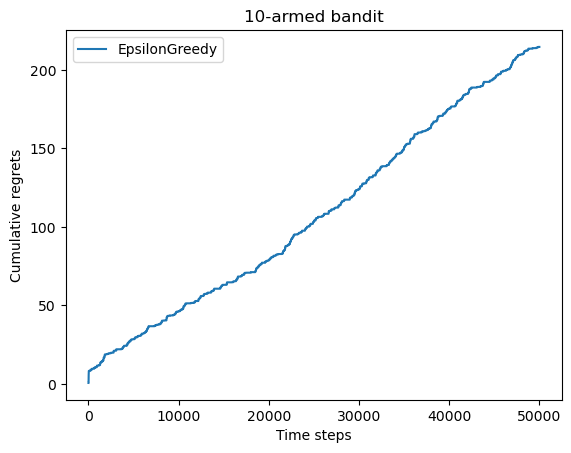

In [6]:
def plot_results(solvers, solver_names):
    """生成累积懊悔随时间变化的图像。输入solvers是一个列表,列表中的每个元素是一种特定的策略。
    而solver_names也是一个列表,存储每个策略的名称"""
    for idx, solver in enumerate(solvers):
        time_list = range(len(solver.regrets))
        plt.plot(time_list, solver.regrets, label=solver_names[idx])
    plt.xlabel('Time steps')
    plt.ylabel('Cumulative regrets')
    plt.title('%d-armed bandit' % solvers[0].bandit.K)
    plt.legend()
    plt.show()


np.random.seed(1)
epsilon_greedy_solver = EpsilonGreedy(bandit_10_arm, epsilon=0.01)
epsilon_greedy_solver.run(50000)
print('epsilon-贪婪算法的累积懊悔为：', epsilon_greedy_solver.regret)
plot_results([epsilon_greedy_solver], ["EpsilonGreedy"])

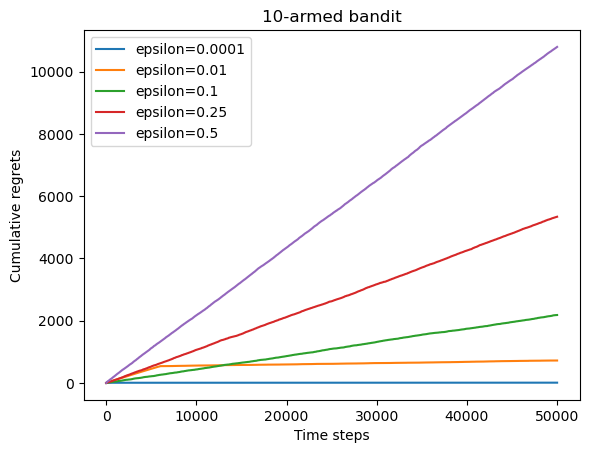

In [7]:
np.random.seed(0)
epsilons = [1e-4, 0.01, 0.1, 0.25, 0.5]
epsilon_greedy_solver_list = [
    EpsilonGreedy(bandit_10_arm, epsilon=e) for e in epsilons
]
epsilon_greedy_solver_names = ["epsilon={}".format(e) for e in epsilons]
for solver in epsilon_greedy_solver_list:
    solver.run(50000)

plot_results(epsilon_greedy_solver_list, epsilon_greedy_solver_names)

epsilon值衰减的贪婪算法的累积懊悔为： 13.397149012382892


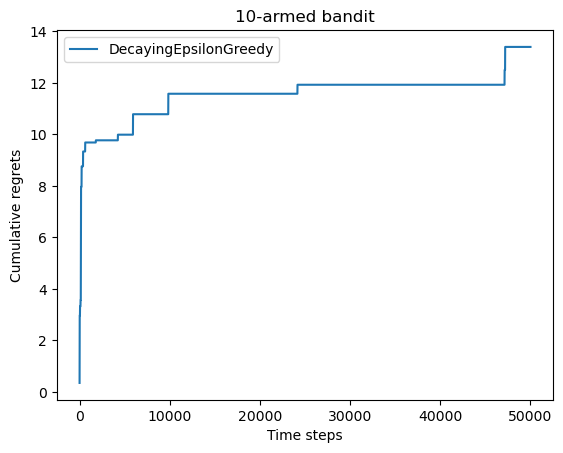

In [8]:
class DecayingEpsilonGreedy(Solver):
    """ epsilon值随时间衰减的epsilon-贪婪算法,继承Solver类 """
    def __init__(self, bandit, init_prob=1.0):
        super(DecayingEpsilonGreedy, self).__init__(bandit)
        self.estimates = np.array([init_prob] * self.bandit.K)
        self.total_count = 0

    def run_one_step(self):
        self.total_count += 1
        if np.random.random() < 1 / self.total_count:  # epsilon值随时间衰减
            k = np.random.randint(0, self.bandit.K)
        else:
            k = np.argmax(self.estimates)

        r = self.bandit.step(k)
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])

        return k


np.random.seed(1)
decaying_epsilon_greedy_solver = DecayingEpsilonGreedy(bandit_10_arm)
decaying_epsilon_greedy_solver.run(50000)
print('epsilon值衰减的贪婪算法的累积懊悔为：', decaying_epsilon_greedy_solver.regret)
plot_results([decaying_epsilon_greedy_solver], ["DecayingEpsilonGreedy"])

上置信界算法的累积懊悔为： 85.54963373433618


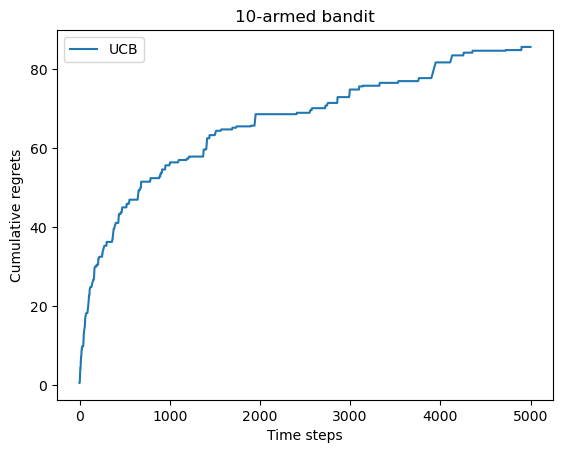

In [9]:
class UCB(Solver):
    """ UCB算法,继承Solver类 """
    def __init__(self, bandit, coef, init_prob=1.0):
        super(UCB, self).__init__(bandit)
        self.total_count = 0
        self.estimates = np.array([init_prob] * self.bandit.K)
        self.coef = coef

    def run_one_step(self):
        self.total_count += 1
        ucb = self.estimates + self.coef * np.sqrt(
            np.log(self.total_count) / (2 * (self.counts + 1)))  # 计算上置信界
        k = np.argmax(ucb)  # 选出上置信界最大的拉杆
        r = self.bandit.step(k)
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])
        return k


np.random.seed(1)
coef = 1  # 控制不确定性比重的系数
UCB_solver = UCB(bandit_10_arm, coef)
UCB_solver.run(5000)
print('上置信界算法的累积懊悔为：', UCB_solver.regret)
plot_results([UCB_solver], ["UCB"])

汤普森采样算法的累积懊悔为： 32.264668204614566


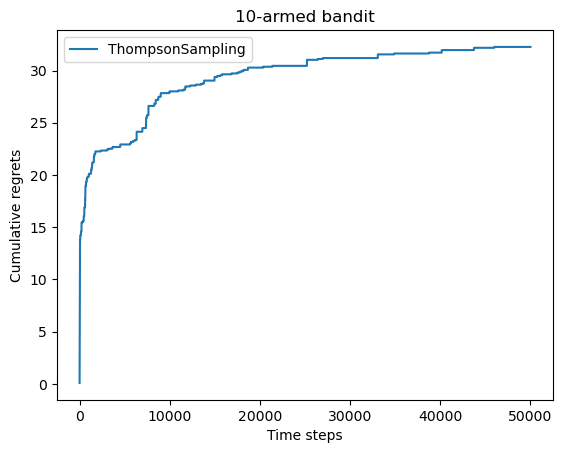

In [10]:
class ThompsonSampling(Solver):
    """ 汤普森采样算法,继承Solver类 """
    def __init__(self, bandit):
        super(ThompsonSampling, self).__init__(bandit)
        self._a = np.ones(self.bandit.K)  # 列表,表示每根拉杆奖励为1的次数
        self._b = np.ones(self.bandit.K)  # 列表,表示每根拉杆奖励为0的次数

    def run_one_step(self):
        samples = np.random.beta(self._a, self._b)  # 按照Beta分布采样一组奖励样本
        k = np.argmax(samples)  # 选出采样奖励最大的拉杆
        r = self.bandit.step(k)

        self._a[k] += r  # 更新Beta分布的第一个参数
        self._b[k] += (1 - r)  # 更新Beta分布的第二个参数
        return k


np.random.seed(1)
thompson_sampling_solver = ThompsonSampling(bandit_10_arm)
thompson_sampling_solver.run(50000)
print('汤普森采样算法的累积懊悔为：', thompson_sampling_solver.regret)
plot_results([thompson_sampling_solver], ["ThompsonSampling"])

In [11]:
np.random.beta([99,1,1],[1,1,1])

array([0.99644906, 0.92420681, 0.02149362])

### 3.2.1 随机过程

**随机过程（stochastic process）** 是概率论的"动力学"部分。概率论的研究对象是静态的随机现象，而随机过程的研究对象是随时间演变的随机现象（例如天气随时间的变化、城市交通随时间的变化）。在随机过程中，随机现象在某时刻的取值是一个向量随机变量，用 $S_t$ 表示，所有可能的状态组成状态集合 $\mathcal{S}$。随机现象便是状态的变化过程。在某时刻 $t$ 的状态 $S_t$ 通常取决于时刻 $t$ 之前的状态。我们将已知历史信息时下一个时刻状态为 $s'$ 的概率表示成 $P(S_{t+1}=s' \mid S_t, S_{t-1}, \dots)$。

### 3.2.2 马尔可夫性质

当且仅当某时刻的状态只取决于上一时刻的状态时，一个随机过程被称为具有**马尔可夫性质（Markov property）**，用公式表示为：

$$P(S_{t+1} \mid S_t) = P(S_{t+1} \mid S_1, S_2, \dots, S_t)$$

也就是说，当前状态是未来的充分统计量，即下一个状态只取决于当前状态，而不会受到过去状态的影响。需要明确的是，具有马尔可夫性并不代表这个随机过程就和历史完全没有关系。因为虽然 $t+1$ 时刻的状态只与 $t$ 时刻的状态有关，但是 $t$ 时刻的状态其实包含了 $t-1$ 时刻的状态的信息，通过这种链式的关系，历史的信息被传递到了现在。马尔可夫性可以大大简化运算，因为只要当前状态可知，所有的历史信息都不再需要了，利用当前状态信息就可以决定未来。

### 3.2.3 马尔可夫过程

**马尔可夫过程（Markov process）** 指具有马尔可夫性质的随机过程，也被称为**马尔可夫链（Markov chain）**。我们通常用元组 $(\mathcal{S}, \mathcal{P})$ 描述一个马尔可夫过程，其中 $\mathcal{S}$ 是有限数量的状态集合，$\mathcal{P}$ 是**状态转移矩阵（state transition matrix）**。假设一共有 $N$ 个状态，此时 $\mathcal{S} = \{s_1, s_2, \dots, s_N\}$。状态转移矩阵 $\mathcal{P}$ 定义了所有状态对之间的转移概率，即

$$\mathcal{P} = \begin{pmatrix}
P(s_1 \mid s_1) & P(s_2 \mid s_1) & \cdots & P(s_N \mid s_1) \\
P(s_1 \mid s_2) & P(s_2 \mid s_2) & \cdots & P(s_N \mid s_2) \\
\vdots & \vdots & \ddots & \vdots \\
P(s_1 \mid s_N) & P(s_2 \mid s_N) & \cdots & P(s_N \mid s_N)
\end{pmatrix}$$

矩阵中第 $i$ 行第 $j$ 列元素 $P_{ij} = P(s_j \mid s_i)$ 表示从状态 $s_i$ 转移到状态 $s_j$ 的概率，我们称为**状态转移函数**。从某个状态出发，到达其他状态的概率和必须为 1，即状态转移矩阵的每一行的和为 1。

下图是一个具有 6 个状态的马尔可夫过程的简单例子。其中每个绿色圆圈表示一个状态，每个状态都有一定概率（包括概率为 0）转移到其他状态，其中 $s_6$ 通常被称为**终止状态（terminal state）**，因为它不会再转移到其他状态，可以理解为它永远以概率 1 转移到自己。状态之间的虚线箭头表示状态的转移，箭头旁的数字表示该状态转移发生的概率。从每个状态出发转移到其他状态的概率总和为 1。例如，$s_1$ 有 90%概率保持不变，有 10%概率转移到 $s_2$，而在 $s_2$ 又有 50%概率回到 $s_1$，有 50%概率转移到 $s_3$。

我们可以写出这个马尔可夫过程的状态转移矩阵：

$$
\mathcal{P} = \begin{pmatrix}
0.9 & 0.1 & 0 & 0 & 0 & 0 \\
0.5 & 0 & 0.5 & 0 & 0 & 0 \\
0 & 0 & 0 & 0.6 & 0 & 0.4 \\
0 & 0 & 0 & 0 & 0.3 & 0.7 \\
0 & 0.2 & 0.3 & 0.5 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

给定一个马尔可夫过程，我们就可以从某个状态出发，根据它的状态转移矩阵生成一个状态序列（episode），这个步骤也被叫做**采样（sampling）**。例如，从 $s_1$ 出发，可以生成序列 $s_1 \to s_1 \to s_1 \to s_2 \to s_3 \to s_6$ 或序列 $s_1 \to s_2 \to s_3 \to s_6$ 等。生成这些序列的概率和状态转移矩阵有关。

In [12]:
import numpy as np
np.random.seed(0)
# 定义状态转移概率矩阵P
P = [
    [0.9, 0.1, 0.0, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.0, 0.4],
    [0.0, 0.0, 0.0, 0.0, 0.3, 0.7],
    [0.0, 0.2, 0.3, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
]
P = np.array(P)

rewards = [-1, -2, -2, 10, 1, 0]  # 定义奖励函数
gamma = 0.5  # 定义折扣因子


# 给定一条序列,计算从某个索引（起始状态）开始到序列最后（终止状态）得到的回报
def compute_return(start_index, chain, gamma):
    G = 0
    for i in reversed(range(start_index,len(chain))):
        print(i)
        G=rewards[i]+gamma*G
    return G


# 一个状态序列,s1-s2-s3-s6
chain = [1, 2, 3, 6]
start_index = 0
G = compute_return(start_index, chain, gamma)
print("根据本序列计算得到回报为：%s。" % G)

3
2
1
0
根据本序列计算得到回报为：-1.25。


In [16]:
x = 0.0
alpha = 0.1

for _ in range(50):
    grad = -2 * (x - 3)
    x = x + alpha * grad
    print(x)

0.6000000000000001
1.08
1.464
1.7711999999999999
2.01696
2.213568
2.3708544
2.49668352
2.597346816
2.6778774528
2.74230196224
2.793841569792
2.8350732558336
2.86805860466688
2.894446883733504
2.9155575069868034
2.932446005589443
2.945956804471554
2.9567654435772432
2.9654123548617948
2.9723298838894356
2.9778639071115487
2.982291125689239
2.985832900551391
2.988666320441113
2.9909330563528904
2.9927464450823122
2.99419715606585
2.99535772485268
2.996286179882144
2.997028943905715
2.9976231551245722
2.9980985240996576
2.9984788192797263
2.998783055423781
2.999026444339025
2.99922115547122
2.9993769243769757
2.9995015395015807
2.9996012316012646
2.9996809852810116
2.999744788224809
2.9997958305798473
2.999836664463878
2.9998693315711025
2.999895465256882
2.9999163722055053
2.999933097764404
2.9999464782115233
2.9999571825692186


In [13]:
# 图3-1 马尔可夫过程的采样实现
import numpy as np

# 定义状态集合：s1=0, s2=1, s3=2, s4=3, s5=4, s6=5
S = [0, 1, 2, 3, 4, 5]

# 定义状态转移概率矩阵 P (对应图3-1)
P = np.array([
    [0.9, 0.1, 0.0, 0.0, 0.0, 0.0],  # s1 -> s1: 0.9, s1 -> s2: 0.1
    [0.5, 0.0, 0.5, 0.0, 0.0, 0.0],  # s2 -> s1: 0.5, s2 -> s3: 0.5
    [0.0, 0.0, 0.0, 0.6, 0.0, 0.4],  # s3 -> s4: 0.6, s3 -> s6: 0.4
    [0.0, 0.0, 0.0, 0.0, 0.3, 0.7],  # s4 -> s5: 0.3, s4 -> s6: 0.7
    [0.0, 0.2, 0.3, 0.5, 0.0, 0.0],  # s5 -> s2: 0.2, s5 -> s3: 0.3, s5 -> s4: 0.5
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],  # s6: 终止状态，永远以概率1转移到自己
])

def sample_episode(start_state, max_steps=20):
    """从起始状态出发，根据状态转移矩阵采样一个状态序列"""
    state = start_state
    episode = [state]
    for _ in range(max_steps):
        # 根据当前状态的行概率分布，采样下一个状态
        next_state = np.random.choice(S, p=P[state])
        episode.append(next_state)
        state = next_state
        # 如果到达终止状态(s6)，停止采样
        if state == 5:
            break
    return episode

# 测试：从 s1 出发，多次采样
np.random.seed(42)
for i in range(5):
    episode = sample_episode(start_state=0)
    episode_names = [f"s{s+1}" for s in episode]
    print(f"序列 {i+1}: {' -> '.join(episode_names)}")

print("\n状态转移矩阵 P 的每一行和为：", P.sum(axis=1))

序列 1: s1 -> s1 -> s2 -> s3 -> s4 -> s5 -> s2 -> s1 -> s1 -> s1 -> s1 -> s1 -> s2 -> s3 -> s4 -> s5 -> s2 -> s1 -> s1 -> s1 -> s1
序列 2: s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s2 -> s3 -> s6
序列 3: s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s2 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s2 -> s3 -> s6
序列 4: s1 -> s1 -> s1 -> s2 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s2 -> s3 -> s4 -> s5
序列 5: s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1

状态转移矩阵 P 的每一行和为： [1. 1. 1. 1. 1. 1.]


> **💡 关键澄清：状态转移矩阵只有一个，不会随 episode 长度改变**

`sample_episode` 每采样一步，都是查**同一个** $P$ 矩阵：

- $P$ 的大小是固定的 $6 \times 6$（因为状态数 $|\mathcal{S}| = 6$），**不**取决于 episode 的长度
- 无论 episode 走 3 步还是 20 步，每一轮都使用这同一个 $P$ 来生成下一个状态
- Episode 的长度只是"在这个矩阵上走了多少步"，跟矩阵本身的大小无关

如果把马尔可夫过程比作一张地图：
- **状态转移矩阵** = 地图本身（fixed）
- **每条 episode** = 在地图上走出的路径（长度可变）
- 不管路径走多长，地图始终是同一张

In [14]:
# ⚡ 直观演示：同一个 P 矩阵，不同长度的 episode

# 同一个 P（6×6），固定不变
print(f"P 矩阵形状 (状态数 × 状态数): {P.shape}")
print()

# 采样 3 条不同长度的 episode，用的都是同一个 P
np.random.seed(123)
for max_len in [5, 10, 20]:
    episode = sample_episode(start_state=0, max_steps=max_len)
    episode_names = [f"s{s+1}" for s in episode]
    print(f"max_steps={max_len:2d} → 实际长度={len(episode):2d} → {' -> '.join(episode_names)}")

print()
print("✅ 同一个 P，可以生成长度完全不同的 episode")
print("✅ P 的大小不随 episode 改变，始终是 6×6")

P 矩阵形状 (状态数 × 状态数): (6, 6)

max_steps= 5 → 实际长度= 6 → s1 -> s1 -> s1 -> s1 -> s1 -> s1
max_steps=10 → 实际长度= 6 → s1 -> s1 -> s2 -> s3 -> s4 -> s6
max_steps=20 → 实际长度=21 → s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1 -> s1

✅ 同一个 P，可以生成长度完全不同的 episode
✅ P 的大小不随 episode 改变，始终是 6×6


### 🔑 重要区分：教科书例子 vs 真实 RL 场景（如 CARLA）

上面的 6 状态马尔可夫链是一个**手写的有穷离散状态**的玩具例子。而在实际 RL（比如 CARLA 自动驾驶）中，情况完全不同：

| 对比维度 | 教科书例子（图3-1） | CARLA 真实场景 |
|:---:|:---:|:---:|
| **状态空间 $\mathcal{S}$** | 有限离散（6个状态） | **无限连续**（图像、雷达、速度、位置…） |
| **转移矩阵 $\mathcal{P}$** | **已知**，手写给出的 $6 \times 6$ | **未知**，$\infty \times \infty$，无法枚举 |
| **概率含义** | $P(s_j \mid s_i) = 0.6$ 明文写在矩阵里 | 概率由**物理引擎**隐式决定，无人知晓具体数值 |

那么 CARLA 中 650 步的 episode 是怎样的？

1. **没有 $650 \times 650$ 的矩阵** — 更没有 $(模拟器分辨率)^2$ 那么大
2. 状态 $s_t$ 是高维连续向量（如摄像头图像 $84 \times 84 \times 3$ → 21,168 维连续空间），理论上矩阵是 $\infty \times \infty$，根本写不出来
3. **step1 → step2 的转换不是"查矩阵"**，而是：车子执行动作 $a_1$（油门/刹车/转向）→ CARLA 物理引擎按动力学方程算 50ms → 得到新的传感器读数 $s_2$
4. 真正用到"概率"的地方：由于物理引擎、传感器噪声、其他交通参与者的随机行为，同样的 $(s_t, a_t)$ 可能产生略有不同的 $s_{t+1}$ — 这个隐式的分布就是 $P(s_{t+1} \mid s_t, a_t)$，但我们**不显式知道它**

**所以这引出了 RL 的核心思想**：既然 $\mathcal{P}$ 未知，我们就不去建模它，而是通过**与环境交互采样大量 episode → 从数据中直接学习最优策略**。这正是 PPO 这类 model-free 算法做的事情。

## 马尔可夫决策过程

In [15]:
import numpy as np
np.random.seed(0)
# 定义状态转移概率矩阵P
P = [
    [0.9, 0.1, 0.0, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.0, 0.4],
    [0.0, 0.0, 0.0, 0.0, 0.3, 0.7],
    [0.0, 0.2, 0.3, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
]
P = np.array(P)

rewards = [-1, -2, -2, 10, 1, 0]  # 定义奖励函数
gamma = 0.5  # 定义折扣因子


# 给定一条序列,计算从某个索引（起始状态）开始到序列最后（终止状态）得到的回报
def compute_return(start_index, chain, gamma):
    G = 0
    for i in reversed(range(start_index, len(chain))):
        G = gamma * G + rewards[chain[i] - 1]
    return G


# 一个状态序列,s1-s2-s3-s6
chain = [1, 2, 3, 6]
start_index = 0
G = compute_return(start_index, chain, gamma)
print("根据本序列计算得到回报为：%s。" % G)

# 根据本序列计算得到回报为：-2.5。

根据本序列计算得到回报为：-2.5。
